[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lijingwang/Machine_Learning_Hydrology/blob/main/02_LSTM_dynamic_inputs.ipynb)

# 02 — LSTM with Dynamic Inputs (Single Catchment)
**ERTH 4750/5750 — Machine Learning and Numerical Modeling in Hydrology | University of Connecticut**

---

## Learning Objectives
- Understand why sequential data requires a different approach than MLP
- Learn the LSTM architecture: cell state, hidden state, and the three gates
- Load **Maurer extended meteorological forcing** (precipitation, temperature, radiation, vapor pressure, day length)
- Prepare multi-variate time series data with **chronological train / validation / test splits**
- Train an LSTM on a **single user-selected catchment** using 6 dynamic forcing variables only
- Evaluate using Nash-Sutcliffe Efficiency (NSE) — the standard hydrology metric
- Compare against a persistence baseline (predicting tomorrow = today)

> **Dynamic inputs only** — the model sees no static catchment attributes. Each site is trained independently.  
> For a multi-catchment model combining static + dynamic inputs, see **03_LSTM_static_dynamic_inputs.ipynb**.

In [38]:
# Google Colab setup (skip if running locally)
!pip install -q numpy pandas matplotlib scikit-learn torch pygeohydro shap

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pygeohydro as gh
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')
%config InlineBackend.figure_format = 'retina'

plt.rcParams['font.size'] = 12
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} | device: {device}')

PyTorch 2.10.0 | device: cpu


---

### Data Required: Maurer Extended Forcing

This notebook uses the **Maurer extended dataset** — basin-averaged daily meteorological forcings (precipitation, temperature, radiation, SWE, vapor pressure, day length) for all 671 CAMELS catchments, covering 1980–2008.

**Download:** https://www.hydroshare.org/resource/17c896843cf940339c3c3496d0c1c077/

- **Local:** download and unzip to a folder called `maurer_extended/` in the same directory as this notebook
- **Colab:** upload `maurer_extended.zip` to your Google Drive root; the setup cell below will unzip it automatically

In [40]:
# ── Google Colab / local setup ────────────────────────────────────────────────
import os, sys

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    MAURER_DIR = '/content/drive/MyDrive/maurer_extended'
    ZIP_PATH   = '/content/drive/MyDrive/maurer_extended.zip'
    if not os.path.exists(MAURER_DIR):
        if os.path.exists(ZIP_PATH):
            print('Unzipping maurer_extended.zip into Drive — one-time only...')
            import zipfile
            with zipfile.ZipFile(ZIP_PATH, 'r') as z:
                z.extractall('/content/drive/MyDrive/')
            print('Done!')
        else:
            raise FileNotFoundError(
                'maurer_extended not found.\n'
                'Upload maurer_extended.zip to your Google Drive root, then re-run this cell.'
            )
else:
    MAURER_DIR = '/Users/lijing.wang/Downloads/maurer_extended'   # local path

print(f'MAURER_DIR : {MAURER_DIR}')
print(f'Exists     : {os.path.exists(MAURER_DIR)}')

MAURER_DIR : /Users/lijing.wang/Downloads/maurer_extended
Exists     : True


---
## Part 1 — Why LSTM for Streamflow?

### The problem with MLP for time series

In notebook `00_MLP`, we predicted **Q90** — a single summary statistic per catchment. Each catchment was one row of features: no time, no order, no memory.

Now we want to predict **daily streamflow** $Q(t)$ from the daily weather history. An MLP has no memory. If you feed it a week of precipitation values, it treats them as independent features with no sense of sequence or causality.

### Recurrent Neural Networks (RNNs)

An RNN processes one timestep at a time and passes a **hidden state** $h_t$ forward:

$$h_t = \tanh(W_h h_{t-1} + W_x x_t + b)$$

The hidden state acts as memory — it carries information from past timesteps. But plain RNNs suffer from the **vanishing gradient problem**: gradients shrink exponentially as they flow back through long sequences, so the model forgets anything more than ~10 timesteps ago.

### LSTM — Long Short-Term Memory

LSTMs solve this with a **cell state** $C_t$ — a separate memory highway that can carry information over hundreds of timesteps. Three **gates** control what is remembered and forgotten:

| Gate | Symbol | What it does |
|------|--------|--------------|
| **Forget gate** | $f_t$ | What fraction of the old cell state to erase |
| **Input gate** | $i_t$ | What new information to write into the cell state |
| **Output gate** | $o_t$ | What part of the cell state to expose as hidden state $h_t$ |

$$f_t = \sigma(W_f [h_{t-1}, x_t] + b_f), \quad i_t = \sigma(W_i [h_{t-1}, x_t] + b_i), \quad o_t = \sigma(W_o [h_{t-1}, x_t] + b_o)$$
$$C_t = f_t \odot C_{t-1} + i_t \odot \tanh(W_C [h_{t-1}, x_t] + b_C), \quad h_t = o_t \odot \tanh(C_t)$$

In hydrology terms, the cell state $C_t$ behaves like **catchment storage** — accumulating precipitation, draining during recessions, and responding to snowmelt — all learned from weather data alone.

---

We use 6 daily forcing variables from the **Maurer extended dataset** as input, following Kratzert et al. (2019):

| Variable | Unit | Physical role |
|----------|------|---------------|
| `dayl` | s/day | Day length — seasonality signal |
| `prcp` | mm/day | Precipitation — primary runoff driver |
| `srad` | W/m² | Solar radiation — drives evapotranspiration |
| `tmax` / `tmin` | °C | Temperature — controls snowmelt & evapotranspiration |
| `vp` | Pa | Vapor pressure — atmospheric humidity |

> Kratzert, F., Klotz, D., Brenner, C., Schulz, K., & Herrnegger, M. (2019). Towards learning universal, regional, and local hydrological behaviors via machine learning applied to large-domain datasets. *Hydrology and Earth System Sciences*, 23(12), 5089–5110.

---
## Part 2 — Data Preparation

### Forcing Data

Meteorological forcing (precipitation, temperature, radiation, SWE, vapor pressure, day length) comes from the **Maurer extended dataset** — basin-averaged daily Daymet-based forcings for all 671 CAMELS catchments, covering 1980–2008.

> Dataset: https://www.hydroshare.org/resource/17c896843cf940339c3c3496d0c1c077/

### Train, Validation, Test Split

Daily streamflow is **not independent** across time — a random split would leak future information into training. We always split **by time**:

| Set | Period | Role |
|-----|--------|------|
| **Train** | 1980–1998 | Model learns from this |
| **Validation** | 1999–2004 | Monitor overfitting, tune hyperparameters |
| **Test** | 2005–2008 | Final honest evaluation — touched once |

The model never sees any future data during training.

In [41]:
import glob

# Load CAMELS (cached after first run)
camels, ts = gh.get_camels()

area_m2 = camels['area_gages2'].values * 1e6
q_mmday = ts['discharge'].values.T * 0.0283168 / area_m2[:, None] * 86400 * 1000

# ── Maurer extended forcing ───────────────────────────────────────────────────
# Note: swe column is present in file headers but is all zeros — excluded
FORCING_VARS = ['dayl', 'prcp', 'srad', 'tmax', 'tmin', 'vp']

maurer_files = {
    os.path.basename(f).split('_')[0]: f
    for f in glob.glob(f'{MAURER_DIR}/**/*.txt', recursive=True)
}
print(f'Maurer files found : {len(maurer_files)} catchments')

# Restrict to Maurer date range (1980–2008) — discharge dates from ts
all_dates  = pd.to_datetime(ts.time.values)
dates      = all_dates[all_dates < '2009-01-01']
q_mmday    = q_mmday[:, all_dates < '2009-01-01']

print(f'Period     : {dates[0].date()} to {dates[-1].date()} ({len(dates):,} days)')

# Chronological split
train_mask = dates < '1999-01-01'
val_mask   = (dates >= '1999-01-01') & (dates < '2005-01-01')
test_mask  = dates >= '2005-01-01'

print(f'\nTrain : {train_mask.sum():,} days  ({dates[train_mask][0].date()} – {dates[train_mask][-1].date()})')
print(f'Val   : {val_mask.sum():,}  days  ({dates[val_mask][0].date()} – {dates[val_mask][-1].date()})')
print(f'Test  : {test_mask.sum():,}  days  ({dates[test_mask][0].date()} – {dates[test_mask][-1].date()})')

Maurer files found : 675 catchments
Period     : 1980-01-01 to 2008-12-31 (10,593 days)

Train : 6,940 days  (1980-01-01 – 1998-12-31)
Val   : 2,192  days  (1999-01-01 – 2004-12-31)
Test  : 1,461  days  (2005-01-01 – 2008-12-31)


In [26]:
import ipywidgets as widgets
from IPython.display import display

name_col  = next((c for c in ['gauge_name', 'name', 'station_nm'] if c in camels.columns), None)
id_to_row = {gid: i for i, gid in enumerate(camels.index)}
EPSILON   = 0.001

# Dropdown with catchment names — select here, then run the next cell
_options = sorted([
    (f"{gid}  —  {camels.loc[gid, name_col] if (name_col and gid in camels.index) else ''}", gid)
    for gid in maurer_files.keys() if gid in camels.index
])
catchment_dropdown = widgets.Dropdown(
    options=_options,
    description='Catchment:',
    layout=widgets.Layout(width='70%'),
)
display(catchment_dropdown)

Dropdown(description='Catchment:', layout=Layout(width='70%'), options=(('01013500  —  Fish River Near Fort Ke…

In [27]:
# Run this cell after selecting from the dropdown above
sel_id = catchment_dropdown.value
name   = camels.loc[sel_id, name_col] if name_col else sel_id
print(f'Selected : {sel_id}  —  {name}')

Selected : 09035900  —  South Fork Of Williams Fork Near Leal, CO


### Sequence Construction — Sliding Window with Forcing

We use a **sliding window** of length `SEQ_LEN = 365` days. At each timestep $t$, the input is the 6 forcing variables over the past 365 days (including day $t$ itself — today's weather is known), and the target is $Q(t)$:

```
Input  x_t : [forcing(t−364), forcing(t−363), …, forcing(t)]   shape: (365, 6)
Target y_t :  Q(t)                                               shape: (1,)
```

Each forcing variable is **independently normalised** with mean/std computed from the **training period only**. The target discharge is **log-transformed** before normalisation to compress the heavy-tailed distribution:

$$\tilde{Q} = \log(Q + \varepsilon), \qquad Q_{\text{norm}} = \frac{\tilde{Q} - \mu_{\text{train}}}{\sigma_{\text{train}}}$$

This prevents the loss from being dominated by rare flood peaks and gives the model a better gradient signal for low-flow periods.

In [28]:
SEQ_LEN = 365

def load_maurer_forcing(gid):
    """
    Load Maurer extended forcing for one catchment.
    Columns in file: Year Mnth Day Hr dayl prcp srad swe tmax tmin vp
    swe is all zeros in this dataset — skip it; read only [4,5,6,8,9,10].
    Returns F: np.ndarray shape (n_days, 6), aligned to `dates`.
    """
    fpath = maurer_files[str(gid)]
    df = pd.read_csv(fpath, sep=r'\s+', skiprows=4,
                     names=['Year','Mnth','Day','Hr','dayl','prcp','srad','swe','tmax','tmin','vp'])
    df['date'] = pd.to_datetime(df[['Year','Mnth','Day']].rename(
                     columns={'Year':'year','Mnth':'month','Day':'day'}))
    df = df.set_index('date').reindex(pd.DatetimeIndex(dates), fill_value=0.0)
    return df[FORCING_VARS].values.astype(np.float32)   # (n_days, 6)


def make_sequences(gid, seq_len=SEQ_LEN):
    row = id_to_row[gid]

    # ── Target: log-normalised discharge ──────────────────────────────────────
    q      = np.where(np.isnan(q_mmday[row]), 0.0, q_mmday[row])
    q_log  = np.log(q + EPSILON)
    mu_q   = q_log[train_mask].mean()
    std_q  = q_log[train_mask].std() + 1e-6
    q_norm = (q_log - mu_q) / std_q

    # ── Forcing matrix: (n_days, 6) ───────────────────────────────────────────
    F = load_maurer_forcing(gid)
    F_norm = F.copy()
    for j in range(len(FORCING_VARS)):
        mu  = F[train_mask, j].mean()
        std = F[train_mask, j].std() + 1e-6
        F_norm[:, j] = (F[:, j] - mu) / std

    # ── Sliding window ────────────────────────────────────────────────────────
    X, y, tidx = [], [], []
    for t in range(seq_len - 1, len(q_norm)):
        X.append(F_norm[t - seq_len + 1 : t + 1])
        y.append(q_norm[t])
        tidx.append(t)

    X    = np.array(X,    dtype=np.float32)
    y    = np.array(y,    dtype=np.float32)
    tidx = np.array(tidx)

    tr = train_mask[tidx]
    vl = val_mask[tidx]
    te = test_mask[tidx]

    return {
        'train':     (X[tr], y[tr]),
        'val':       (X[vl], y[vl]),
        'test':      (X[te], y[te]),
        'mu': mu_q, 'std': std_q,
        'q_norm':    q_norm,
        'test_tidx': tidx[te],
    }


catchment_data = make_sequences(sel_id)
X_tr, y_tr = catchment_data['train']
print(f'Train sequences : {len(X_tr):,}   input shape: {X_tr.shape}')
print(f'Val   sequences : {len(catchment_data["val"][0]):,}')
print(f'Test  sequences : {len(catchment_data["test"][0]):,}')

Train sequences : 6,576   input shape: (6576, 365, 6)
Val   sequences : 2,192
Test  sequences : 1,461


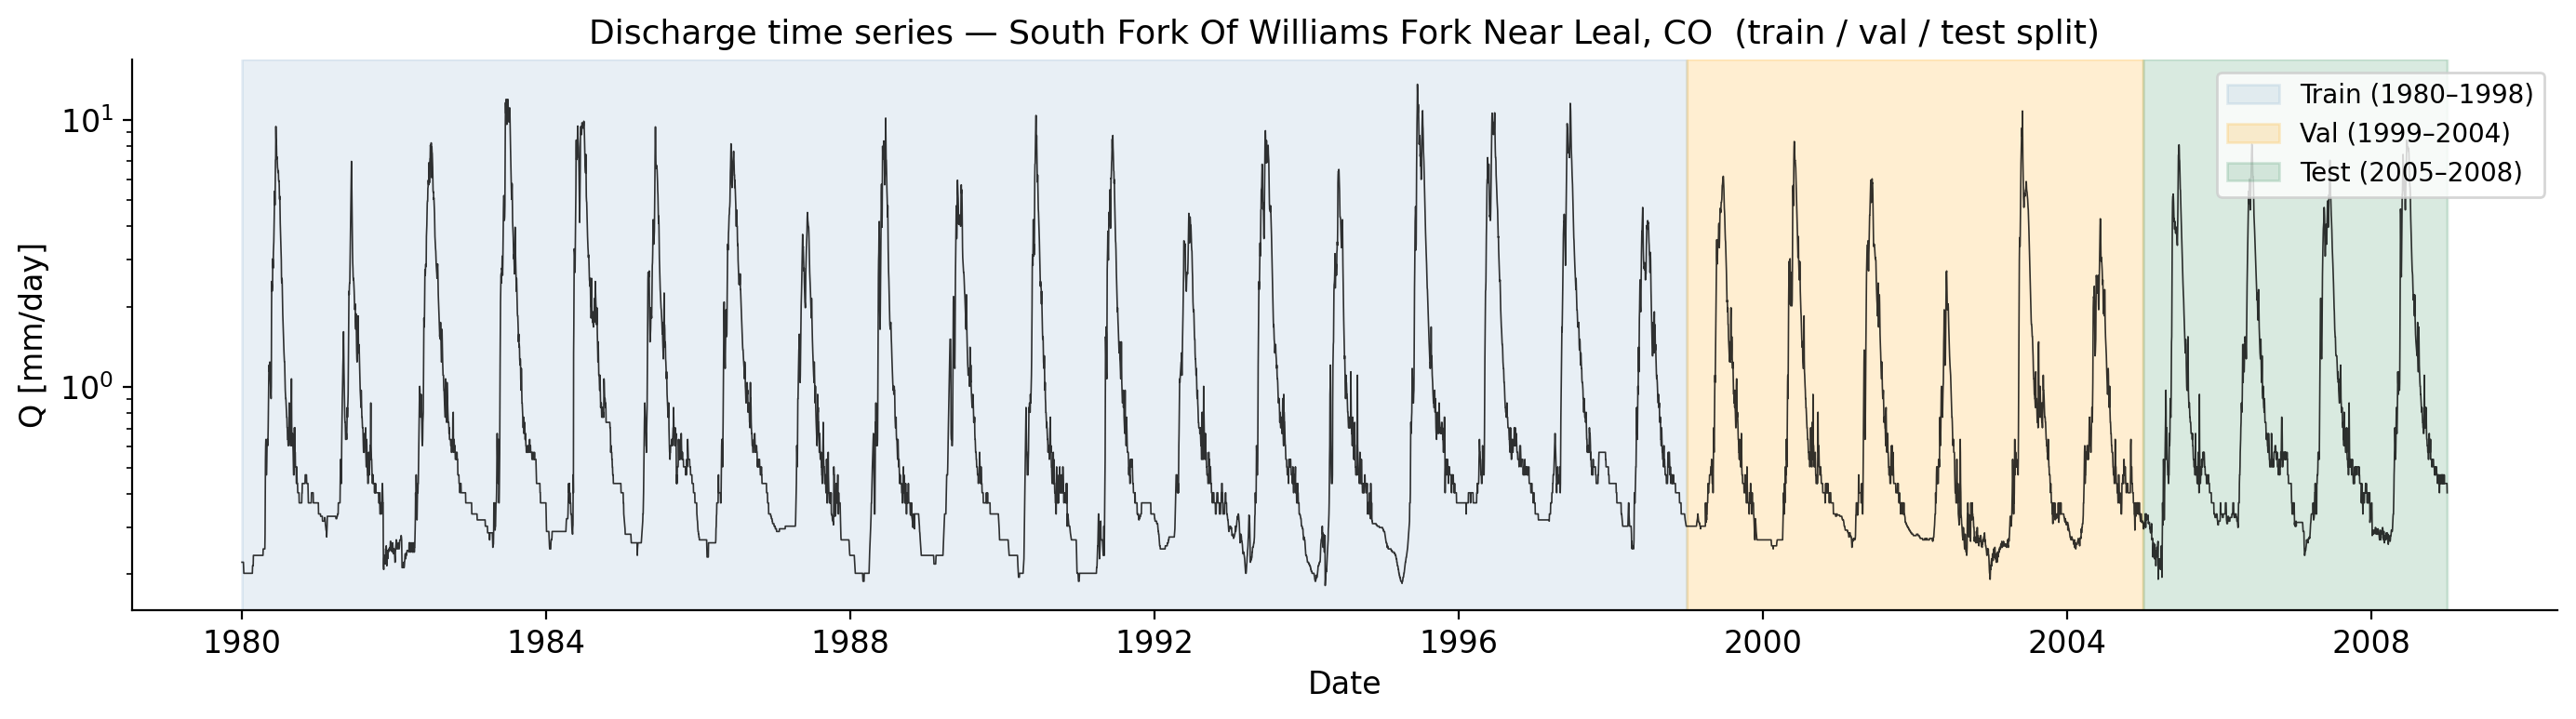

In [29]:
# ── Train / Val / Test discharge time series ─────────────────────────────────
row   = id_to_row[sel_id]
q_raw = q_mmday[row]

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(dates, 0, 1, where=train_mask,
                transform=ax.get_xaxis_transform(),
                color='steelblue', alpha=0.12, label='Train (1980–1998)')
ax.fill_between(dates, 0, 1, where=val_mask,
                transform=ax.get_xaxis_transform(),
                color='orange', alpha=0.18, label='Val (1999–2004)')
ax.fill_between(dates, 0, 1, where=test_mask,
                transform=ax.get_xaxis_transform(),
                color='seagreen', alpha=0.18, label='Test (2005–2008)')
ax.plot(dates, q_raw, color='k', lw=0.6, alpha=0.8)
ax.set_yscale('log')
ax.set_ylabel('Q [mm/day]')
ax.set_xlabel('Date')
ax.set_title(f'Discharge time series — {name}  (train / val / test split)', fontsize=13)
ax.legend(fontsize=10, loc='upper right')
plt.tight_layout();  plt.show()

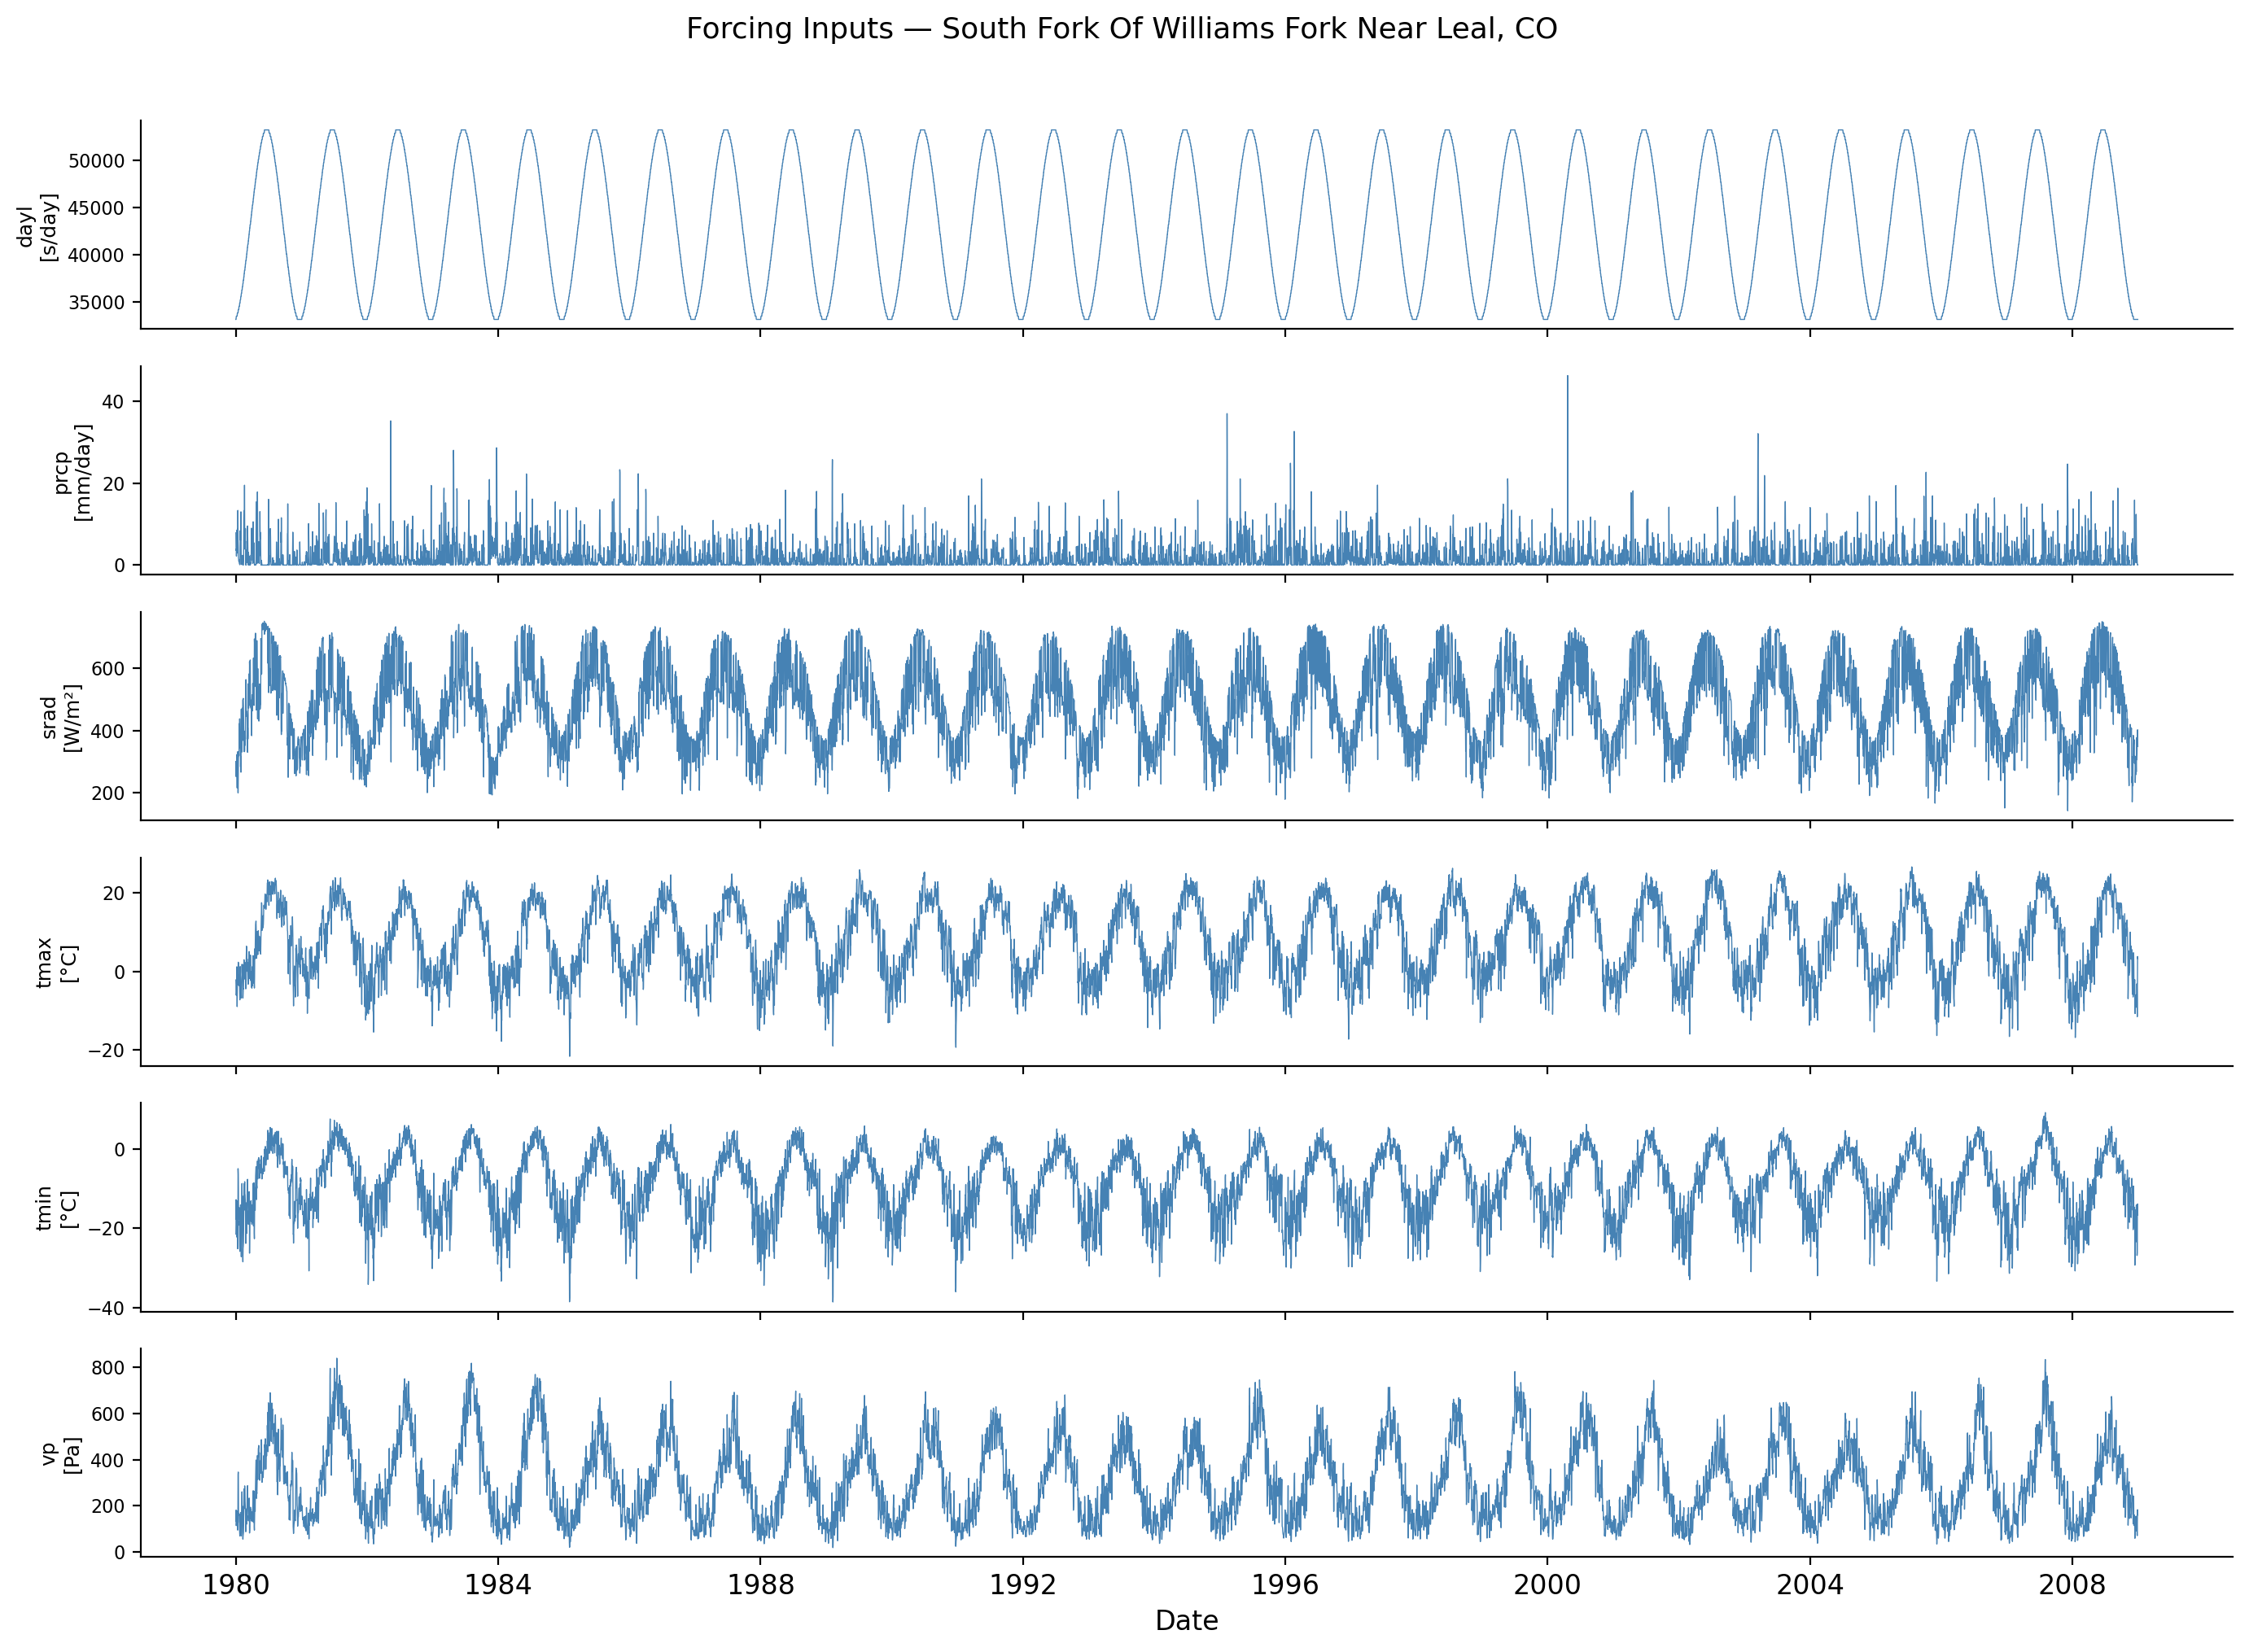

In [30]:
# ── Input forcing variables ───────────────────────────────────────────────────
F_raw = load_maurer_forcing(sel_id)
units = {'dayl': 's/day', 'prcp': 'mm/day', 'srad': 'W/m²',
         'tmax': '°C', 'tmin': '°C', 'vp': 'Pa'}

fig, axes = plt.subplots(len(FORCING_VARS), 1, figsize=(14, 10), sharex=True)
for ax, var, vals in zip(axes, FORCING_VARS, F_raw.T):
    ax.plot(dates, vals, lw=0.5, color='steelblue')
    ax.set_ylabel(f'{var}\n[{units[var]}]', fontsize=9)
    ax.tick_params(axis='y', labelsize=8)

axes[-1].set_xlabel('Date')
plt.suptitle(f'Forcing Inputs — {name}', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## Part 3 — Build the LSTM

In [31]:
class LSTMModel(nn.Module):
    """
    Many-to-one LSTM: takes a sequence of daily forcing vectors,
    returns the predicted discharge for the current day.
    """
    def __init__(self, input_size=6, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True,          # (batch, seq, features)
            dropout     = dropout if num_layers > 1 else 0.0
        )
        self.fc = nn.Linear(hidden_size, 1)   # no activation — regression

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        _, (h_n, _) = self.lstm(x)
        last_hidden = h_n[-1]            # (batch, hidden_size)
        return self.fc(last_hidden)      # (batch, 1)


model = LSTMModel(input_size=len(FORCING_VARS), hidden_size=64,
                  num_layers=2, dropout=0.2).to(device)
print(model)
n_params = sum(p.numel() for p in model.parameters())
print(f'\nInput  : (batch, {SEQ_LEN}, {len(FORCING_VARS)})  ← {len(FORCING_VARS)} forcing vars × 365 days')
print(f'Total parameters: {n_params:,}')

LSTMModel(
  (lstm): LSTM(6, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

Input  : (batch, 365, 6)  ← 6 forcing vars × 365 days
Total parameters: 51,777


---
## Part 4 — Train

### NSE — Nash-Sutcliffe Efficiency

In hydrology we report **NSE** instead of R²:

$$\text{NSE} = 1 - \frac{\sum(Q_{obs} - Q_{pred})^2}{\sum(Q_{obs} - \bar{Q}_{obs})^2}$$

| NSE | Interpretation |
|-----|----------------|
| **1.0** | Perfect prediction |
| **0.0** | No better than predicting the mean |
| **< 0** | Worse than predicting the mean |

NSE > 0.7 is generally considered good in hydrology.

We train one model per catchment to keep things clear — each catchment gets its own LSTM tuned to its hydrology.

In [32]:
def nse(obs, sim):
    return 1 - np.sum((obs - sim)**2) / np.sum((obs - np.mean(obs))**2)


def train_lstm(data, n_epochs=10, lr=1e-3, batch_size=128):
    X_tr, y_tr = data['train']
    X_vl, y_vl = data['val']

    train_loader = DataLoader(
        TensorDataset(torch.FloatTensor(X_tr), torch.FloatTensor(y_tr).unsqueeze(-1)),
        batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(
        TensorDataset(torch.FloatTensor(X_vl), torch.FloatTensor(y_vl).unsqueeze(-1)),
        batch_size=batch_size, shuffle=False)

    m    = LSTMModel(input_size=len(FORCING_VARS),
                     hidden_size=64, num_layers=2, dropout=0.2).to(device)
    opt  = torch.optim.Adam(m.parameters(), lr=lr)
    crit = nn.MSELoss()

    train_losses, val_losses = [], []
    for epoch in range(n_epochs):
        m.train()
        bl = []
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = crit(m(Xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(m.parameters(), 1.0)
            opt.step()
            bl.append(loss.item())

        train_losses.append(float(np.mean(bl)))

        m.eval()
        vl = []
        with torch.no_grad():
            for Xb, yb in val_loader:
                Xb, yb = Xb.to(device), yb.to(device)
                vl.append(crit(m(Xb), yb).item())
        val_losses.append(float(np.mean(vl)))

        print(f'Epoch {epoch+1:3d}/{n_epochs}  train={train_losses[-1]:.4f}  val={val_losses[-1]:.4f}', flush=True)

    return m, train_losses, val_losses


In [33]:
name = camels.loc[sel_id, name_col] if name_col else sel_id
print(f'Training LSTM for {sel_id} — {name}')
model, train_losses, val_losses = train_lstm(catchment_data, n_epochs=10, lr=1e-3)

Training LSTM for 09035900 — South Fork Of Williams Fork Near Leal, CO
Epoch   1/10  train=0.4162  val=0.1253
Epoch   2/10  train=0.1092  val=0.0831
Epoch   3/10  train=0.0869  val=0.0715
Epoch   4/10  train=0.0695  val=0.0609
Epoch   5/10  train=0.0698  val=0.0632
Epoch   6/10  train=0.0616  val=0.0747
Epoch   7/10  train=0.0550  val=0.0563
Epoch   8/10  train=0.0526  val=0.0705
Epoch   9/10  train=0.0508  val=0.0513
Epoch  10/10  train=0.0469  val=0.0661


---
## Part 5 — Training Curves

Check for:
- **Both decreasing** → healthy training
- **Val loss rising while train falls** → overfitting — the model is memorising the training period
- **Both plateau high** → underfitting — increase model capacity or train longer

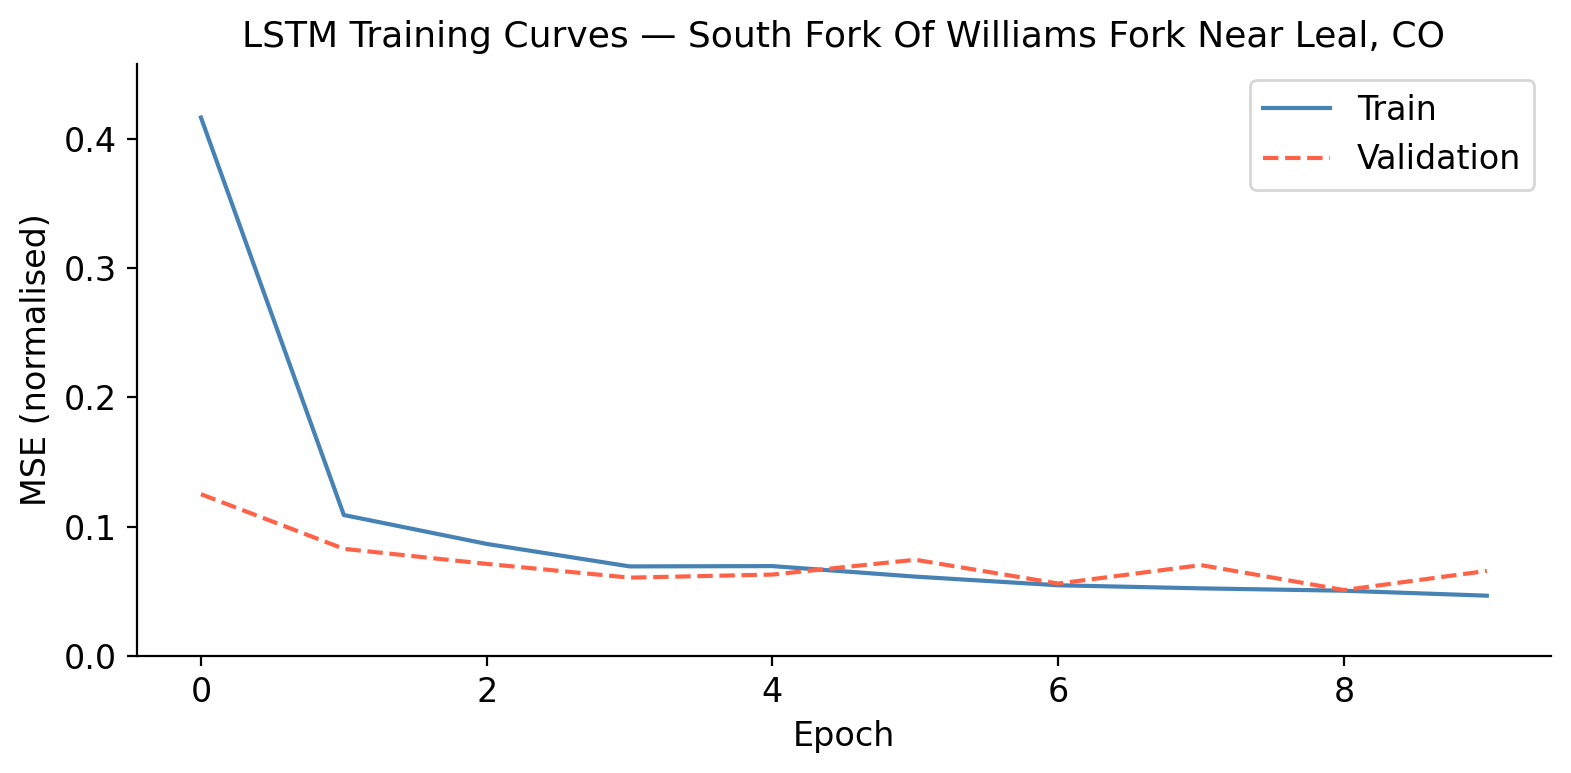

In [34]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_losses, color='steelblue', lw=1.5, label='Train')
ax.plot(val_losses,   color='tomato',    lw=1.5, ls='--', label='Validation')
ax.set_xlabel('Epoch');  ax.set_ylabel('MSE (normalised)')
ax.set_ylim(0, max(max(train_losses), max(val_losses)) * 1.1)
ax.legend()
name = camels.loc[sel_id, name_col] if name_col else sel_id
ax.set_title(f'LSTM Training Curves — {name}', fontsize=13)
plt.tight_layout();  plt.show()

---
## Part 6 — Evaluate on All Splits

We evaluate on **train, validation, and test** periods. The test period (2005–2008) is the honest final evaluation — data the model has never seen.

We also compute a **persistence baseline**: predict tomorrow's flow = today's flow. This is the simplest possible forecast and a fair benchmark — if our LSTM can't beat it, it has learned nothing useful.

In [35]:
EVAL_BATCH = 512   # reduce if you still see OOM

def evaluate_split(data, m, split):
    mu, std = data['mu'], data['std']
    X_s, y_s = data[split]
    X_all = torch.FloatTensor(X_s)

    m.eval()
    preds = []
    with torch.no_grad():
        for start in range(0, len(X_all), EVAL_BATCH):
            batch = X_all[start : start + EVAL_BATCH].to(device)
            preds.append(m(batch).cpu())
    y_pred_norm = torch.cat(preds).numpy().flatten()

    y_pred = np.maximum(np.exp(y_pred_norm * std + mu) - EPSILON, 0)
    y_obs  = np.maximum(np.exp(y_s         * std + mu) - EPSILON, 0)

    q_norm_full  = data['q_norm']
    tidx         = data[f'{split}_tidx'] if f'{split}_tidx' in data else None
    if tidx is not None:
        persist_norm = np.array([q_norm_full[t - 1] for t in tidx])
        y_persist    = np.maximum(np.exp(persist_norm * std + mu) - EPSILON, 0)
    else:
        y_persist = None

    return y_obs, y_pred, y_persist


# Store tidx for all splits
for split, mask in [('train', train_mask), ('val', val_mask), ('test', test_mask)]:
    X_s, y_s = catchment_data[split]
    _, _, tidx_all = [], [], []
    row = id_to_row[sel_id]
    q   = np.where(np.isnan(q_mmday[row]), 0.0, q_mmday[row])
    tidx_s = np.array([t for t in range(SEQ_LEN - 1, len(q)) if mask[t]])
    catchment_data[f'{split}_tidx'] = tidx_s

results = {}
name = camels.loc[sel_id, name_col] if name_col else sel_id
print(f'{'Split':<8} {'NSE (LSTM)':>12} {'NSE (persist)':>15} {'RMSE':>10}')
print('-' * 50)
for split in ['train', 'val', 'test']:
    y_obs, y_pred, y_persist = evaluate_split(catchment_data, model, split)
    results[split] = dict(obs=y_obs, pred=y_pred, persist=y_persist,
                          tidx=catchment_data[f'{split}_tidx'])
    nse_m = nse(y_obs, y_pred)
    nse_p = nse(y_obs, y_persist) if y_persist is not None else float('nan')
    rmse  = np.sqrt(np.mean((y_obs - y_pred)**2))
    print(f'{split:<8} {nse_m:>12.3f} {nse_p:>15.3f} {rmse:>10.4f}')

Split      NSE (LSTM)   NSE (persist)       RMSE
--------------------------------------------------
train           0.951           0.986     0.4159
val             0.762           0.985     0.6462
test            0.828           0.988     0.6849


---
## Part 7 — Visualise Predictions on Test Period

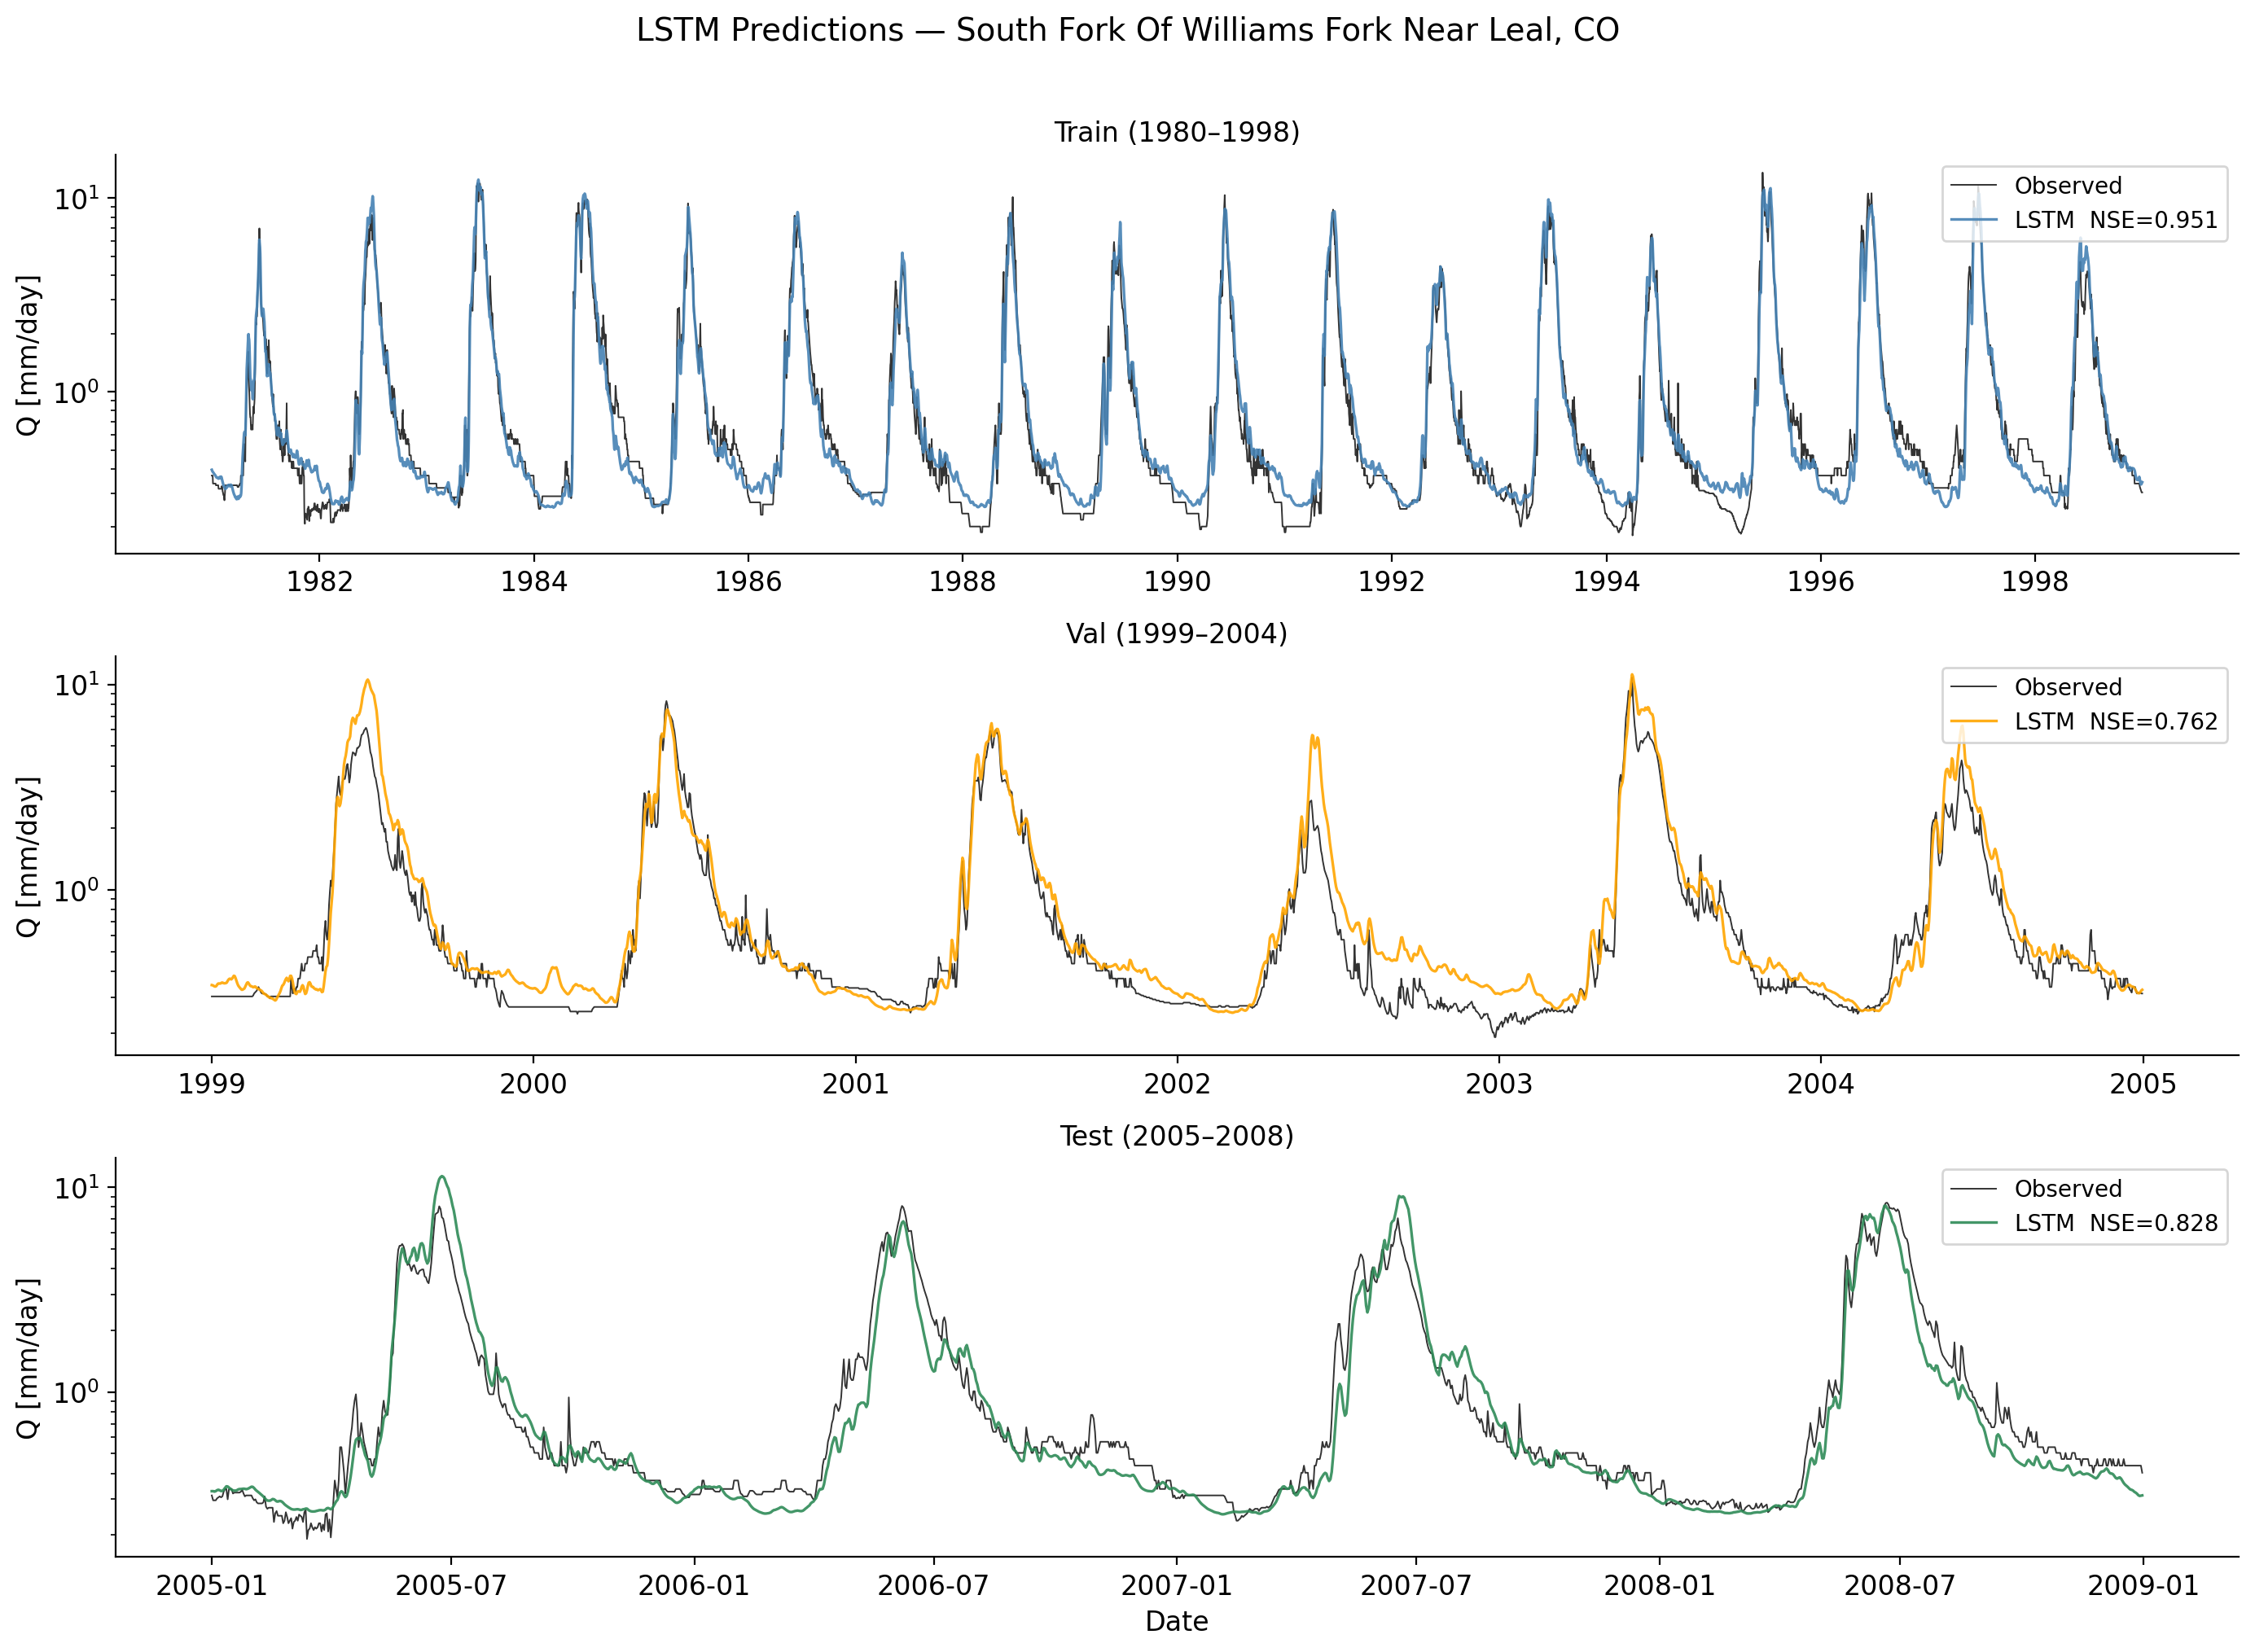

In [36]:
split_colors = {'train': 'steelblue', 'val': 'orange', 'test': 'seagreen'}
split_labels = {'train': 'Train (1980–1998)', 'val': 'Val (1999–2004)', 'test': 'Test (2005–2008)'}

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)

for ax, split in zip(axes, ['train', 'val', 'test']):
    r    = results[split]
    t    = dates[r['tidx']]
    obs  = r['obs']
    pred = r['pred']
    nse_val = nse(obs, pred)

    ax.plot(t, obs,  color='k',                  lw=0.7, alpha=0.8, label='Observed')
    ax.plot(t, pred, color=split_colors[split],  lw=1.2, alpha=0.9, label=f'LSTM  NSE={nse_val:.3f}')
    ax.set_yscale('log')
    ax.set_ylabel('Q [mm/day]')
    ax.set_title(split_labels[split], fontsize=12)
    ax.legend(fontsize=10, loc='upper right')

axes[-1].set_xlabel('Date')
plt.suptitle(f'LSTM Predictions — {name}', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### Observed vs Predicted Scatter

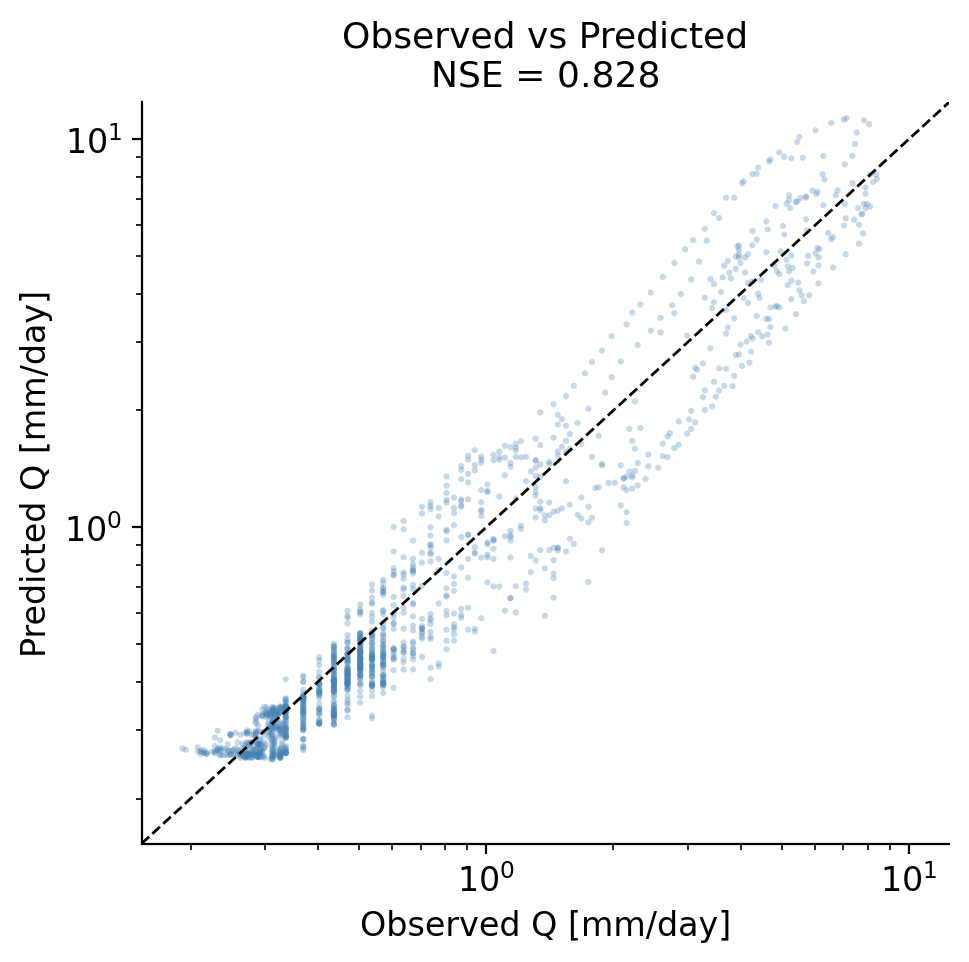

In [37]:
lim = [min(y_obs.min(), y_pred.min()) * 0.8, max(y_obs.max(), y_pred.max()) * 1.1]

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(y_obs, y_pred, s=5, alpha=0.3, color='steelblue', edgecolors='none')
ax.plot(lim, lim, 'k--', lw=1)
ax.set_xscale('log');  ax.set_yscale('log')
ax.set_xlim(lim);      ax.set_ylim(lim)
ax.set_xlabel('Observed Q [mm/day]')
ax.set_ylabel('Predicted Q [mm/day]')
ax.set_title(f'Observed vs Predicted\nNSE = {nse(y_obs, y_pred):.3f}', fontsize=13)
plt.tight_layout();  plt.show()

---
## Part 8 — SHAP Explanations

### Why SHAP on an LSTM is different from an MLP

In notebook 01, each input sample was a **1D vector** of 28 static catchment attributes — SHAP returned one importance value per feature.

Here, each input sample is a **2D matrix — (365 days × 6 forcing variables)**. SHAP now returns a **(365 × 6)** attribution matrix per prediction: every feature at every timestep gets its own importance score. This lets us ask not just *which variable mattered* but *when* it mattered.

### How GradientExplainer works on sequential input

**Step 1 — Define a baseline.** We take 50 random training sequences as background. Their average represents *"a typical day — no anomaly, no signal"*.

**Step 2 — Blend toward the baseline.** For a test sequence $x$, we create a series of intermediate inputs:

$$x_\alpha = \alpha \cdot x + (1 - \alpha) \cdot x_{\text{background}}, \quad \alpha \in [0, 1]$$

At $\alpha = 1$ we have the actual test input. At $\alpha = 0$ we have the background. The blend gradually "switches off" the test signal.

**Step 3 — Compute gradients at each blend.** At every blended input, we ask: *"if I nudge forcing variable $j$ on day $t$ slightly, how much does today's predicted discharge change?"* That is $\partial f / \partial x_{t,j}$. This requires running backpropagation through the LSTM — the gradient at day $t$ travels backward through hidden states $h_t \to h_{t-1} \to \cdots \to h_1$, which is why older timesteps can still carry a signal.

**Step 4 — Average the gradients.** The SHAP value for variable $j$ on day $t$ is the average of those gradients across all blend steps, scaled by how far the input is from the background:

$$\phi_{t,j} = (x_{t,j} - x^{\text{bg}}_{t,j}) \cdot \overline{\frac{\partial f}{\partial x_{t,j}}}$$

A large $|\phi_{t,j}|$ means: *"this variable, on this day, was far from its normal value and the model is sensitive to that deviation."*

### What the plots show

| Plot | How it's computed | Question answered |
|------|-------------------|-------------------|
| **Feature importance** | Mean \|SHAP\| averaged over all 365 timesteps and all 50 test samples | Which of the 6 forcing variables drives predictions most overall? |
| **Memory depth** | Mean \|SHAP\| averaged over all 6 features and all 50 test samples, plotted vs. lag | How many days back does the model actually use? |

In [38]:
import shap

# ── Background: random subset of training sequences ───────────────────────────
# Kept small (50) — GradientExplainer runs one forward+backward pass per
# background sample × test sample, so BG_SIZE × N_EXPLAIN drives runtime.
np.random.seed(42)
BG_SIZE   = 50
N_EXPLAIN = 50

bg_idx = np.random.choice(len(catchment_data['train'][0]), BG_SIZE, replace=False)
X_bg   = torch.FloatTensor(catchment_data['train'][0][bg_idx]).to(device)

te_idx = np.random.choice(len(catchment_data['test'][0]), N_EXPLAIN, replace=False)
X_te   = torch.FloatTensor(catchment_data['test'][0][te_idx]).to(device)

# ── Compute SHAP values ───────────────────────────────────────────────────────
model.eval()
explainer = shap.GradientExplainer(model, X_bg)
shap_raw  = explainer.shap_values(X_te)

# shap_values returns a list (one array per output) in older SHAP,
# or a bare array in newer SHAP — handle both
sv = shap_raw[0] if isinstance(shap_raw, list) else shap_raw

# Remove any size-1 dimensions (some SHAP versions add an output dim)
sv = np.squeeze(sv)   # e.g. (N, 1, 6, 365) or (N, 1, 365, 6) → (N, 6, 365) or (N, 365, 6)

# Guarantee shape is (N_EXPLAIN, SEQ_LEN, n_features)
if sv.ndim == 3 and sv.shape[1] == len(FORCING_VARS) and sv.shape[2] == SEQ_LEN:
    sv = sv.transpose(0, 2, 1)   # (N, n_features, SEQ_LEN) → (N, SEQ_LEN, n_features)

print(f'SHAP tensor shape: {sv.shape}  →  (samples={sv.shape[0]}, timesteps={sv.shape[1]}, features={sv.shape[2]})')

SHAP tensor shape: (50, 365, 6)  →  (samples=50, timesteps=365, features=6)


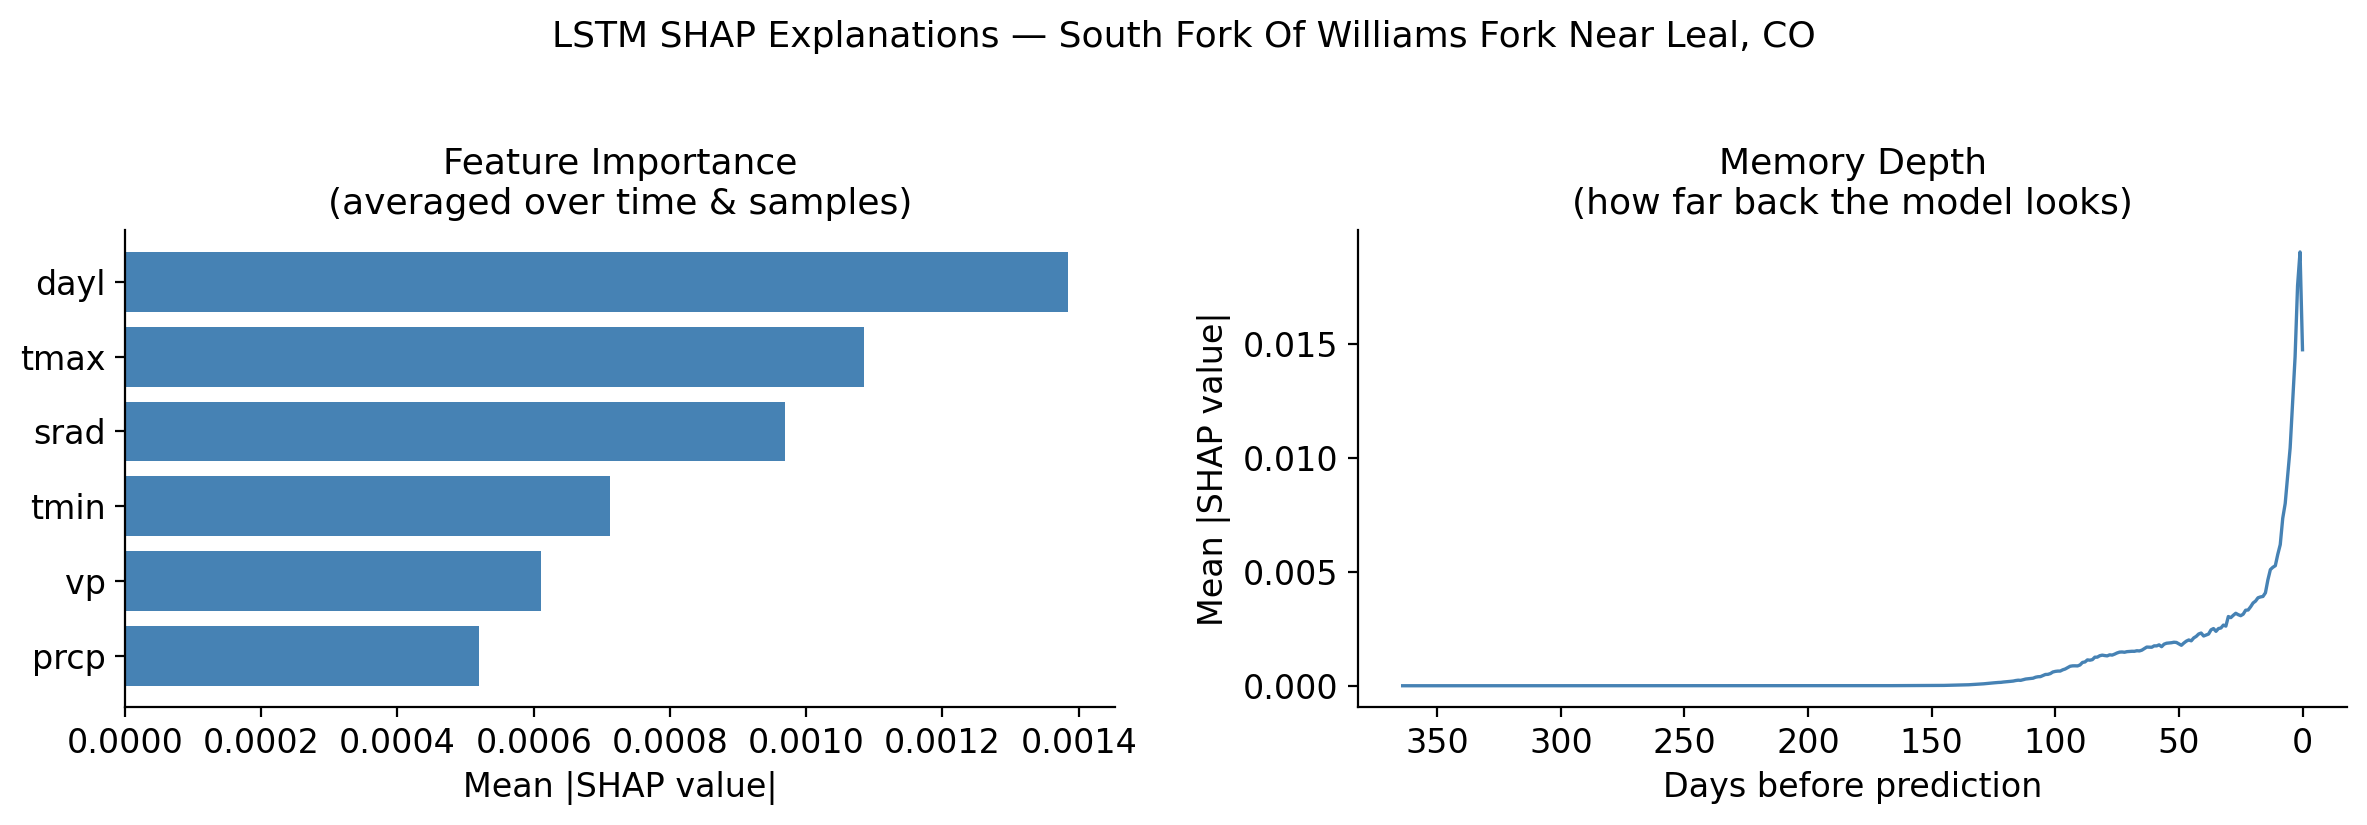

In [39]:
units = {'dayl': 's/day', 'prcp': 'mm/day', 'srad': 'W/m²',
         'tmax': '°C',    'tmin': '°C',      'vp':   'Pa'}

lag = np.arange(SEQ_LEN - 1, -1, -1)   # 364 days ago → today (0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── Feature importance (mean |SHAP| averaged over time & samples) ─────────────
mean_imp = np.abs(sv).mean(axis=(0, 1)).flatten()
order    = np.argsort(mean_imp)[::-1]
labels   = [FORCING_VARS[int(i)] for i in order]
axes[0].barh(labels, mean_imp[order], color='steelblue')
axes[0].set_xlabel('Mean |SHAP value|')
axes[0].set_title('Feature Importance\n(averaged over time & samples)', fontsize=13)
axes[0].invert_yaxis()

# ── Memory depth (mean |SHAP| averaged over features & samples) ───────────────
temporal = np.abs(sv).mean(axis=(0, 2)).flatten()
axes[1].plot(lag, temporal, color='steelblue', lw=1.2)
axes[1].set_xlabel('Days before prediction')
axes[1].set_ylabel('Mean |SHAP value|')
axes[1].set_title('Memory Depth\n(how far back the model looks)', fontsize=13)
axes[1].invert_xaxis()

plt.suptitle(f'LSTM SHAP Explanations — {name}', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## Summary

### LSTM vs MLP — key differences

| | MLP (notebook 00) | LSTM (this notebook) |
|---|---|---|
| **Target** | Q90 — one static value per catchment | Q(t) — daily time series |
| **Input** | 28 static catchment attributes | 6 daily Maurer forcing variables × 365 days |
| **Memory** | None — treats each sample independently | Cell state carries storage signal across 365 days |
| **Split** | Random (catchments are independent) | **Chronological** (time is ordered) |
| **Metric** | R², RMSE | NSE, RMSE |

### Why chronological split matters

A random split on daily discharge would leak future information into training. Always split by time for any sequential prediction task.

### Persistence baseline

Always compare against persistence (Q(t) = Q(t−1)). Streamflow is strongly autocorrelated — a "copy yesterday" model achieves NSE > 0.7 on many humid catchments. A forcing-driven LSTM should clearly exceed this by learning event dynamics: rising limbs, recession curves, and snowmelt onset.

### Next step — EA-LSTM (Kratzert et al. 2019)

Kratzert et al. extended this by conditioning the LSTM's input gate on **28 static catchment attributes** (aridity, soil depth, geology, vegetation, etc.). This **Entity-Aware LSTM** trains on all 671 catchments simultaneously and learns a shared rainfall-runoff function, with the static attributes providing the "personality" of each catchment. See **03_LSTM_static_dynamic_inputs.ipynb**.